In [102]:
import pandas as pd
import numpy as np
import warnings 
import holidays
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import koreanize_matplotlib
from glob import glob
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
warnings.filterwarnings('ignore')

In [103]:
station_files = glob('../../Data/Zero/2024/*.csv')
station_files = sorted(station_files)
station_files

['../../Data/Zero/2024/data_2401.csv',
 '../../Data/Zero/2024/data_2402.csv',
 '../../Data/Zero/2024/data_2403.csv',
 '../../Data/Zero/2024/data_2404.csv',
 '../../Data/Zero/2024/data_2405.csv',
 '../../Data/Zero/2024/data_2406.csv',
 '../../Data/Zero/2024/data_2407.csv',
 '../../Data/Zero/2024/data_2408.csv',
 '../../Data/Zero/2024/data_2409.csv',
 '../../Data/Zero/2024/data_2410.csv',
 '../../Data/Zero/2024/data_2411.csv',
 '../../Data/Zero/2024/data_2412.csv']

In [117]:
# 'ST-464', 'ST-481', 'ST-479', 
# 'ST-2247', 'ST-2252', 'ST-2425', 
# 'ST-1027', 'ST-2263', 'ST-3126', 
# 'ST-1035', 'ST-454', 'ST-471', 
# 'ST-1024', 'ST-1023', 'ST-450',
# 'ST-1034', 'ST-462', 'ST-2264'

target_station = [949, 906, 923]

In [105]:
tmp_raw =[]
for file_name in station_files:
    tmp = pd.read_csv(file_name, header=0,encoding='cp949')
    tmp_raw.append(tmp)
    
station_raw = pd.concat(tmp_raw)   
station_raw

,일시,대여소번호,대여소명,시간대,거치대수량
0,2024-01-01,101,101. (구)합정동 주민센터,0,0
1,2024-01-01,102,102. 망원역 1번출구 앞,0,51
2,2024-01-01,103,103. 망원역 2번출구 앞,0,20
3,2024-01-01,104,104. 합정역 1번출구 앞,0,3
4,2024-01-01,105,105. 합정역 5번출구 앞,0,0
...,...,...,...,...,...
2335244,2024-12-31,6172,6172. 가양5단지아파트,23,6
2335245,2024-12-31,6173,6173. 서울자동차운전전문학원,23,10
2335246,2024-12-31,6176,6176. 유광사 여성병원 앞,23,2
2335247,2024-12-31,6177,6177. 마곡롯데캐슬르웨스트,23,12


In [118]:
df = station_raw[station_raw['대여소번호'].isin(target_station)]
df.reset_index(drop=True,inplace=True)
stations = {station_id: group.reset_index(drop=True)
            for station_id, group in df.groupby('대여소번호')}

stations

{906:                일시  대여소번호            대여소명  시간대  거치대수량
 0      2024-01-01    906  906. 연신내역 5번출구    0     17
 1      2024-01-01    906  906. 연신내역 5번출구    1     16
 2      2024-01-01    906  906. 연신내역 5번출구    2     13
 3      2024-01-01    906  906. 연신내역 5번출구    3      8
 4      2024-01-01    906  906. 연신내역 5번출구    4      3
 ...           ...    ...             ...  ...    ...
 10870  2024-12-31    906  906. 연신내역 5번출구   19     25
 10871  2024-12-31    906  906. 연신내역 5번출구   20     23
 10872  2024-12-31    906  906. 연신내역 5번출구   21     25
 10873  2024-12-31    906  906. 연신내역 5번출구   22     26
 10874  2024-12-31    906  906. 연신내역 5번출구   23     27
 
 [10875 rows x 5 columns],
 923:               일시  대여소번호            대여소명  시간대  거치대수량
 0     2024-01-01    923  923. 국민은행 연서지점    0      2
 1     2024-01-01    923  923. 국민은행 연서지점    1      2
 2     2024-01-01    923  923. 국민은행 연서지점    2      3
 3     2024-01-01    923  923. 국민은행 연서지점    3      3
 4     2024-01-01    923  923. 국민은행 연서지점    4   

In [119]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

model_df = df.copy()
model_df['일시'] = pd.to_datetime(model_df['일시'])
model_df = model_df.sort_values(['대여소번호', '일시']).reset_index(drop=True)

model_df['hour'] = model_df['일시'].dt.hour
model_df['dayofweek'] = model_df['일시'].dt.dayofweek
model_df['month'] = model_df['일시'].dt.month
model_df['day'] = model_df['일시'].dt.day
model_df['is_weekend'] = (model_df['dayofweek'] >= 5).astype(int)

model_df['target'] = model_df['거치대수량']

model_df['lag_1'] = model_df.groupby('대여소번호')['거치대수량'].shift(1)
model_df['lag_2'] = model_df.groupby('대여소번호')['거치대수량'].shift(2)
model_df['lag_3'] = model_df.groupby('대여소번호')['거치대수량'].shift(3)
model_df['lag_24'] = model_df.groupby('대여소번호')['거치대수량'].shift(24)

model_df['rolling_mean_3'] = (
    model_df.groupby('대여소번호')['거치대수량']
    .transform(lambda x: x.shift(1).rolling(3).mean())
)

model_df['rolling_mean_24'] = (
    model_df.groupby('대여소번호')['거치대수량']
    .transform(lambda x: x.shift(1).rolling(24).mean())
)

train_df = model_df.dropna().reset_index(drop=True)

features = [
    '대여소번호', 'hour', 'dayofweek', 'month', 'day', 'is_weekend',
    'lag_1', 'lag_2', 'lag_3', 'lag_24',
    'rolling_mean_3', 'rolling_mean_24'
]

X = train_df[features]
y = train_df['target']


In [120]:
n = len(train_df)

train_end = int(n * 0.7)
valid_end = int(n * 0.85)

X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]

X_valid = X.iloc[train_end:valid_end]
y_valid = y.iloc[train_end:valid_end]

X_test = X.iloc[valid_end:]
y_test = y.iloc[valid_end:]

print('train:', X_train.shape, y_train.shape)
print('valid:', X_valid.shape, y_valid.shape)
print('test :', X_test.shape, y_test.shape)

train: (20951, 12) (20951,)
valid: (4489, 12) (4489,)
test : (4490, 12) (4490,)


In [121]:
model = RandomForestRegressor(
    random_state=42,
    n_estimators=200,
    max_depth=10
)

model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [122]:
def evaluate(y_true, y_pred, name='dataset'):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    print(f'[{name}]')
    print(f'R2   : {r2:.4f}')
    print(f'MAE  : {mae:.4f}')
    print(f'RMSE : {rmse:.4f}')
    print()


In [123]:
train_pred = model.predict(X_train)
valid_pred = model.predict(X_valid)
test_pred = model.predict(X_test)

evaluate(y_train, train_pred, 'train')
evaluate(y_valid, valid_pred, 'valid')
evaluate(y_test, test_pred, 'test')


[train]
R2   : 0.9569
MAE  : 1.3874
RMSE : 2.1117

[valid]
R2   : 0.8788
MAE  : 1.9046
RMSE : 3.0458

[test]
R2   : 0.9099
MAE  : 1.7249
RMSE : 2.6157



====================

In [112]:
import matplotlib.pyplot as plt

valid_result = train_df.iloc[train_end:valid_end][['일시', '대여소번호', 'target']].copy()
valid_result['pred'] = valid_pred

test_result = train_df.iloc[valid_end:][['일시', '대여소번호', 'target']].copy()
test_result['pred'] = test_pred


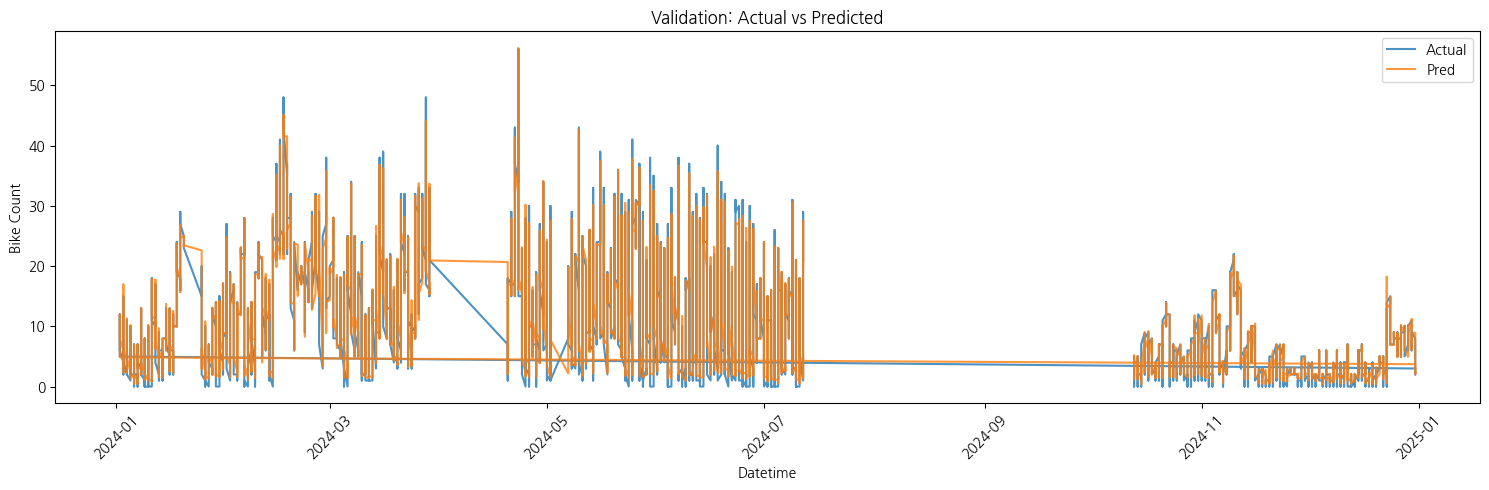

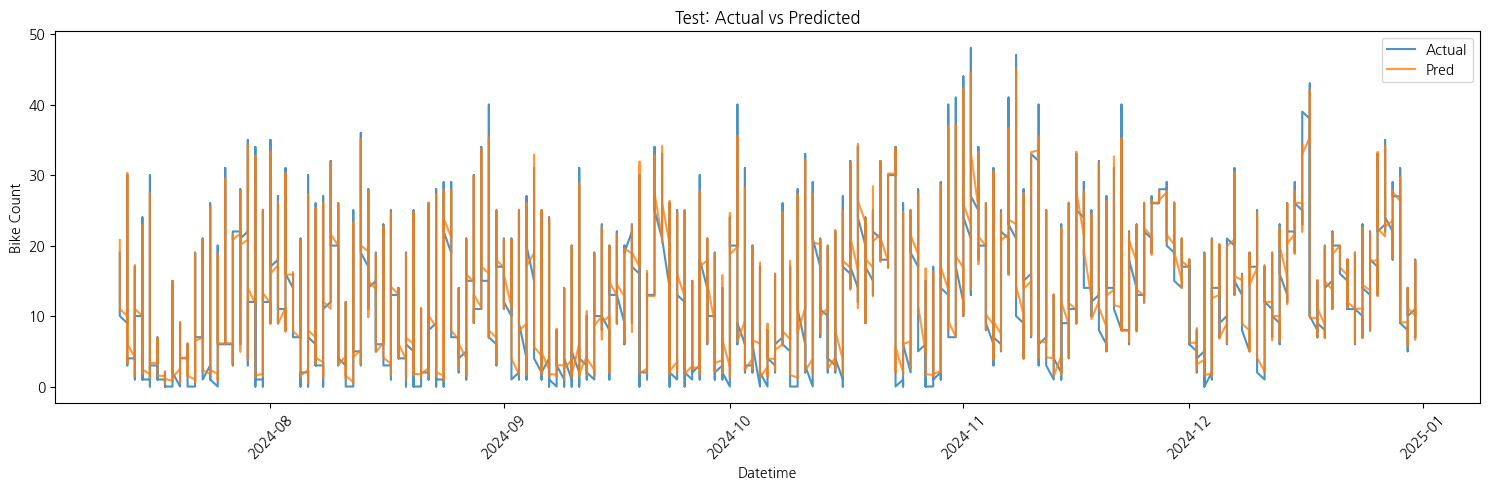

In [113]:
plt.figure(figsize=(15, 5))
plt.plot(valid_result['일시'], valid_result['target'], label='Actual', alpha=0.8)
plt.plot(valid_result['일시'], valid_result['pred'], label='Pred', alpha=0.8)
plt.title('Validation: Actual vs Predicted')
plt.xlabel('Datetime')
plt.ylabel('Bike Count')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 5))
plt.plot(test_result['일시'], test_result['target'], label='Actual', alpha=0.8)
plt.plot(test_result['일시'], test_result['pred'], label='Pred', alpha=0.8)
plt.title('Test: Actual vs Predicted')
plt.xlabel('Datetime')
plt.ylabel('Bike Count')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


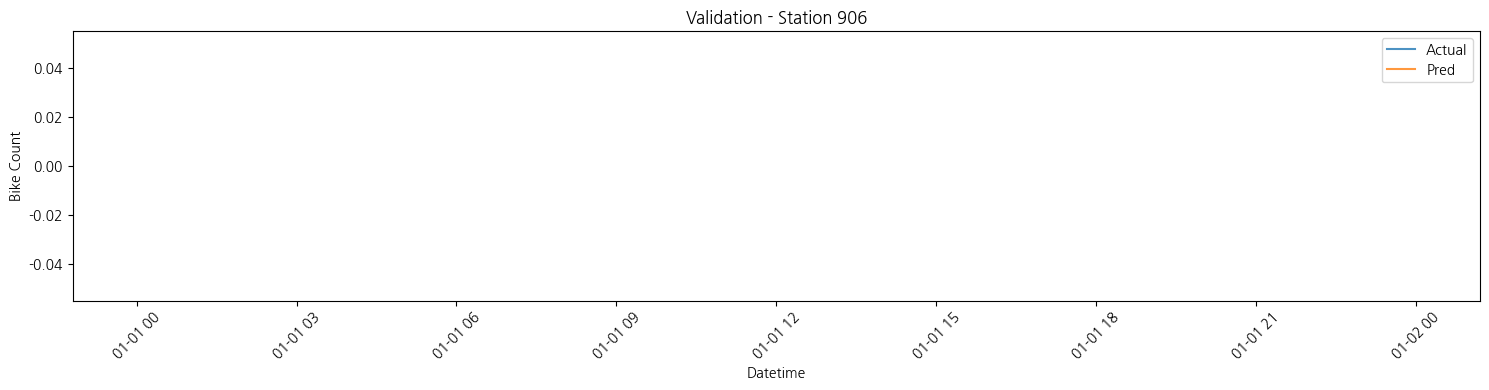

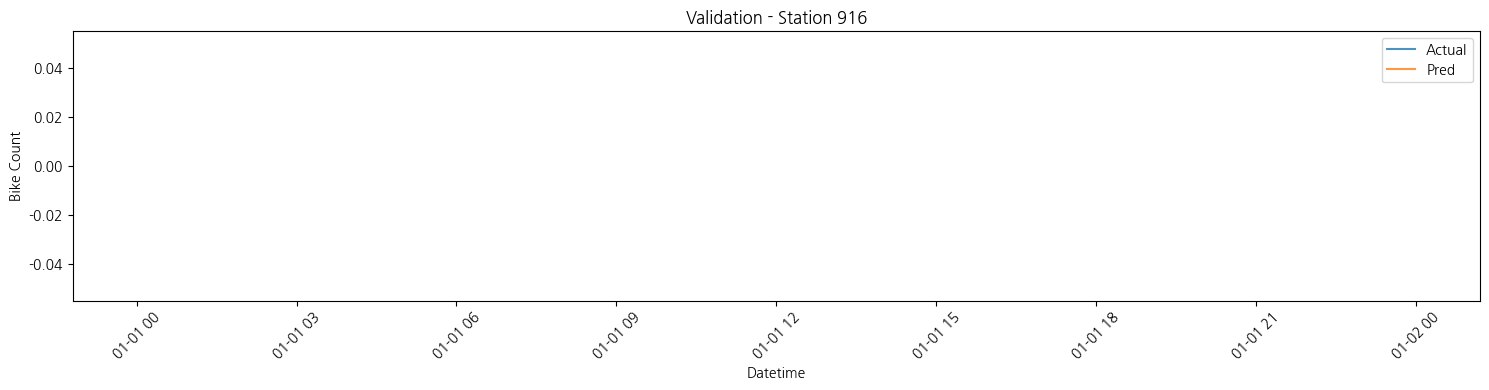

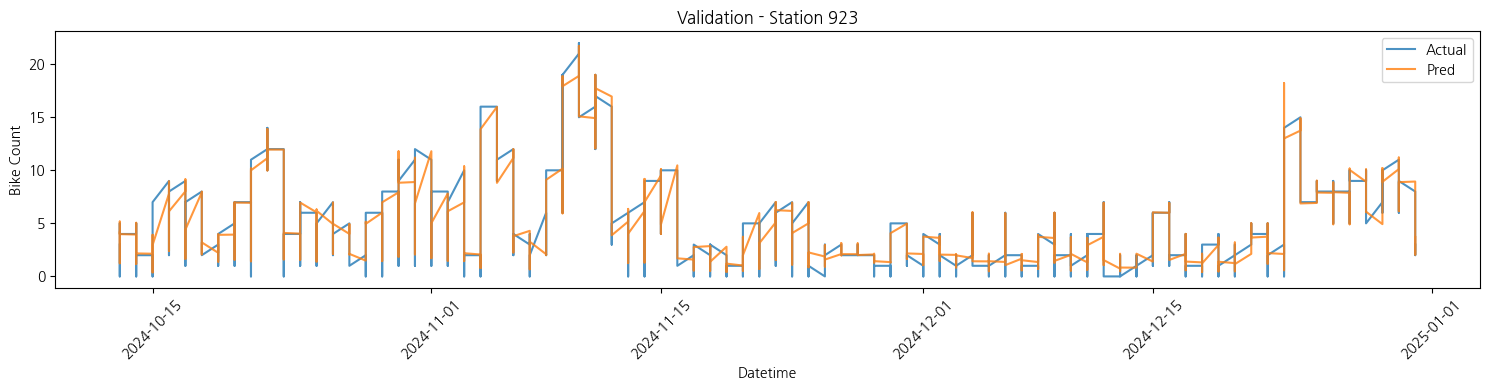

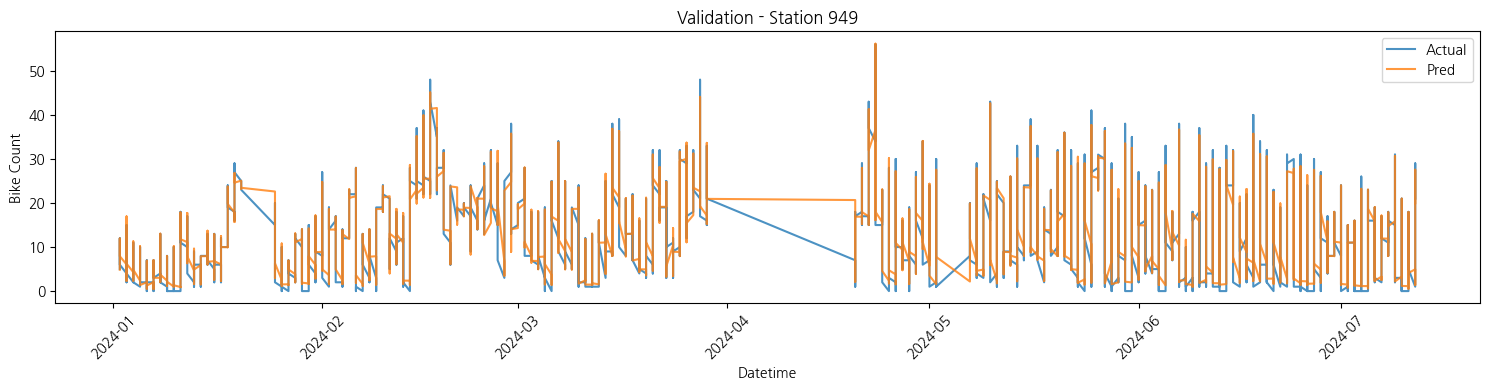

In [114]:
station_ids = sorted(train_df['대여소번호'].unique())

for station_id in station_ids:
    temp = valid_result[valid_result['대여소번호'] == station_id]
    
    plt.figure(figsize=(15, 4))
    plt.plot(temp['일시'], temp['target'], label='Actual', alpha=0.8)
    plt.plot(temp['일시'], temp['pred'], label='Pred', alpha=0.8)
    plt.title(f'Validation - Station {station_id}')
    plt.xlabel('Datetime')
    plt.ylabel('Bike Count')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


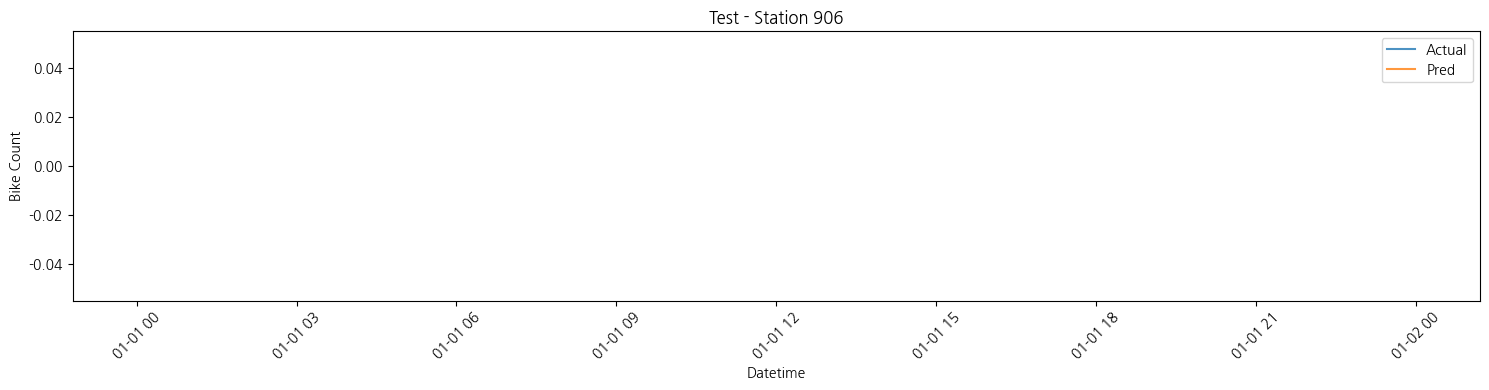

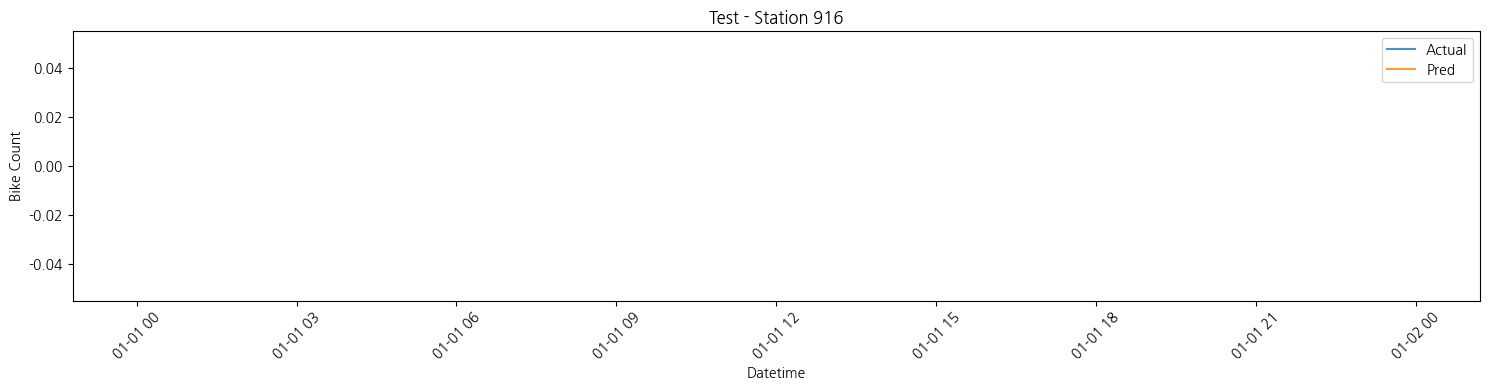

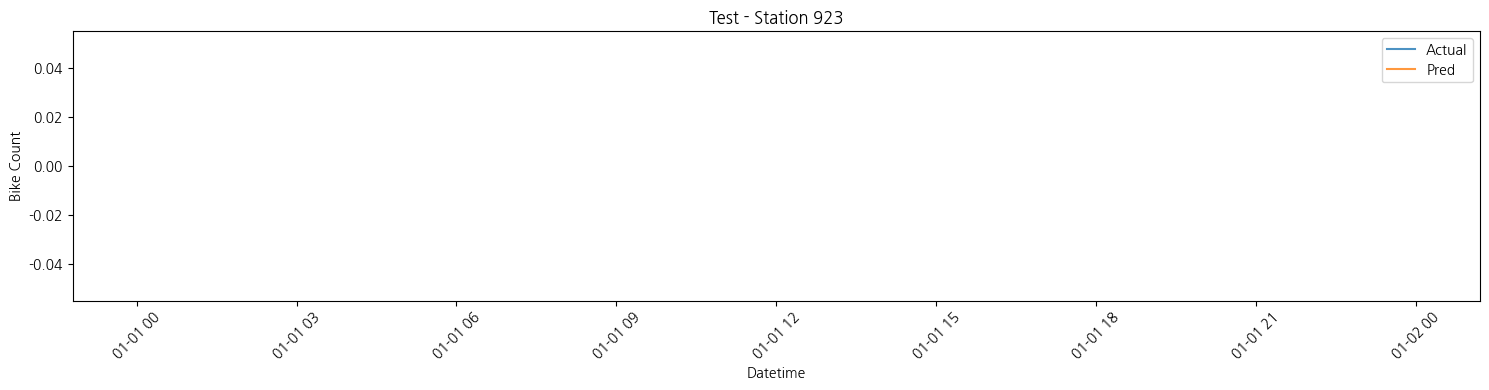

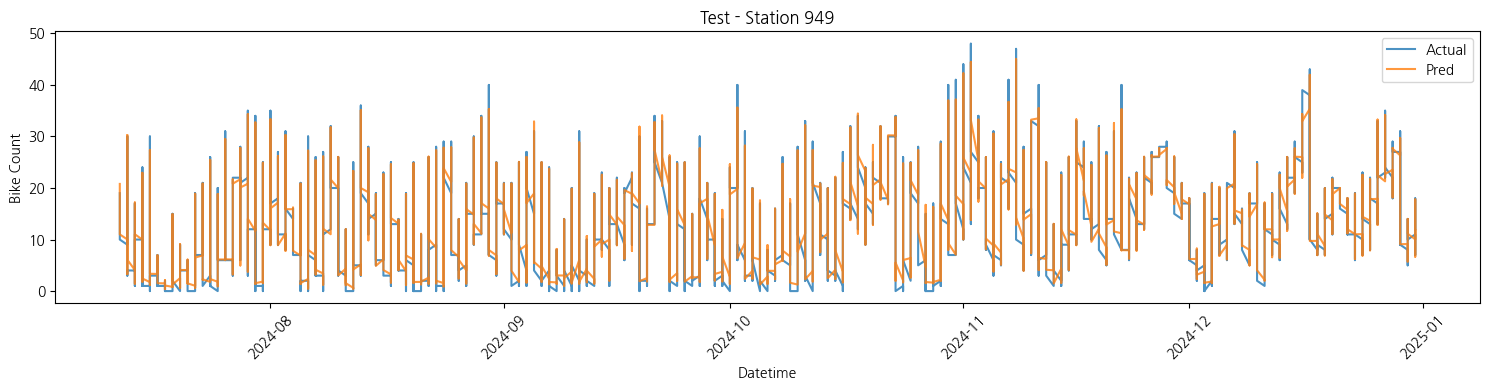

In [115]:
for station_id in station_ids:
    temp = test_result[test_result['대여소번호'] == station_id]
    
    plt.figure(figsize=(15, 4))
    plt.plot(temp['일시'], temp['target'], label='Actual', alpha=0.8)
    plt.plot(temp['일시'], temp['pred'], label='Pred', alpha=0.8)
    plt.title(f'Test - Station {station_id}')
    plt.xlabel('Datetime')
    plt.ylabel('Bike Count')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


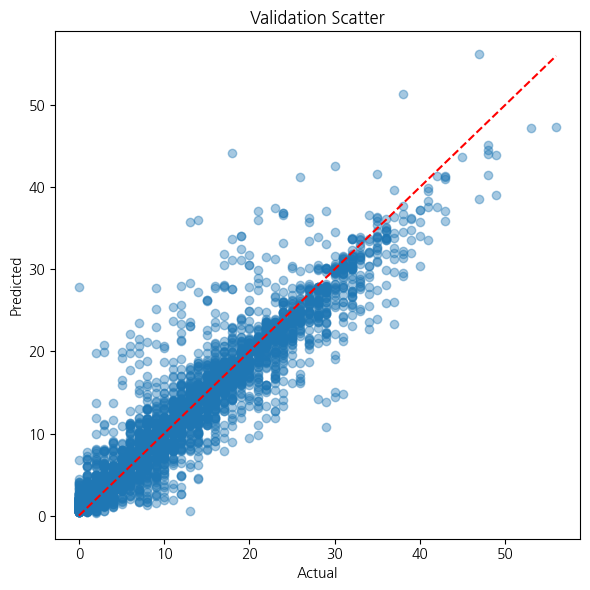

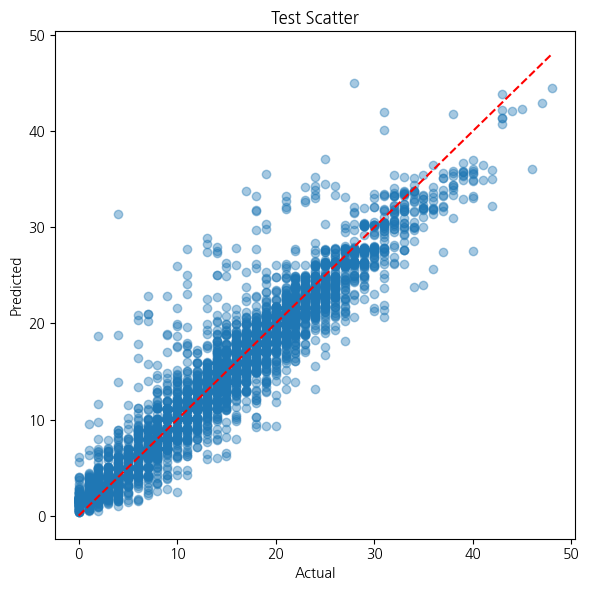

In [116]:
plt.figure(figsize=(6, 6))
plt.scatter(y_valid, valid_pred, alpha=0.4)
plt.plot([y_valid.min(), y_valid.max()], [y_valid.min(), y_valid.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Validation Scatter')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(y_test, test_pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Test Scatter')
plt.tight_layout()
plt.show()
